Dataset Head:
     customer name                                    customer e-mail  \
0    Martina Avila  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu   
1    Harlan Barnes                                eu.dolor@diam.co.uk   
2  Naomi Rodriquez  vulputate.mauris.sagittis@ametconsectetueradip...   
3  Jade Cunningham                            malesuada@dignissim.com   
4     Cedric Leach     felis.ullamcorper.viverra@egetmollislectus.net   

        country  gender        age  annual Salary  credit card debt  \
0      Bulgaria       0  41.851720    62812.09301      11609.380910   
1        Belize       0  40.870623    66646.89292       9572.957136   
2       Algeria       1  43.152897    53798.55112      11160.355060   
3  Cook Islands       1  58.271369    79370.03798      14426.164850   
4        Brazil       1  57.313749    59729.15130       5358.712177   

     net worth  car purchase amount  
0  238961.2505          35321.45877  
1  530973.9078          45115.52566  
2  638

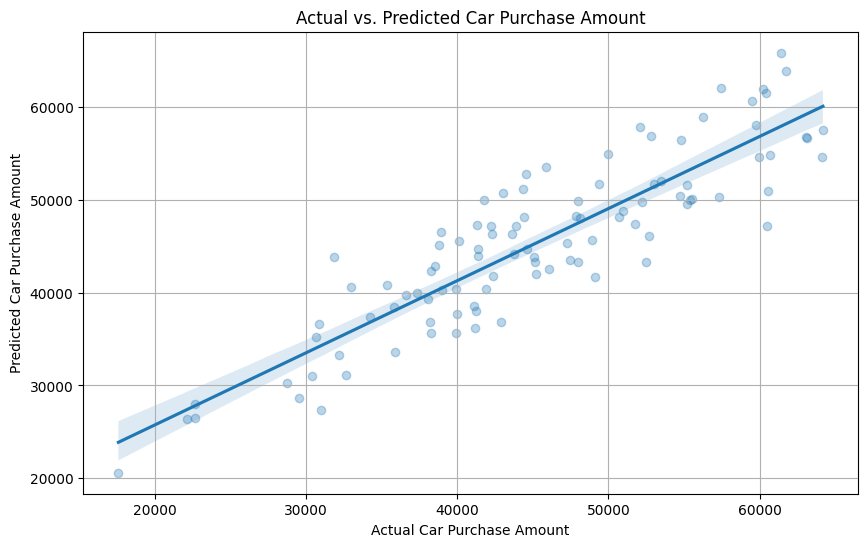

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('car_purchasing.csv', encoding='latin1') # Using latin1 encoding as it's common for some CSVs

# Display the first few rows and check column names
print("Dataset Head:")
print(df.head())
print("\nDataset Info:")
df.info()

# Assuming relevant columns for prediction are 'Age', 'Annual Salary'
# and the target is 'Car Purchase Amount'

# Drop irrelevant columns or those that might cause data leakage if not handled carefully
# For simplicity, let's select numerical features that seem relevant to car purchasing
# Based on typical car purchasing datasets, 'Gender' and 'Dealer Name' might need encoding or could be less impactful
# Let's focus on numerical features first.

# Identify features (X) and target (y)
# Let's use 'Age' and 'Annual Salary' as features to predict 'Car Purchase Amount'
X = df[['age', 'annual Salary']]
y = df['car purchase amount']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\nLinear Regression Model Performance:")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Optional: Visualize actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Car Purchase Amount")
plt.ylabel("Predicted Car Purchase Amount")
plt.title("Actual vs. Predicted Car Purchase Amount")
plt.grid(True)
plt.show()

In [5]:
import joblib
joblib.dump(model, 'model.joblib')

['model.joblib']

In [6]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

# Load the trained model
# Ensure 'model.joblib' exists from previous steps where the model was saved
try:
    model = joblib.load('model.joblib')
    print("Model loaded successfully!")
except FileNotFoundError:
    print("Error: model.joblib not found. Please ensure the model is trained and saved.")
    model = None # Set model to None to prevent errors if not found

@app.route('/predict', methods=['POST'])
def predict():
    if model is None:
        return jsonify({'error': 'Model not loaded.'}), 500

    try:
        data = request.get_json(force=True)

        # Expecting input like: {'age': 45, 'annual_salary': 60000}
        age = data.get('age')
        annual_salary = data.get('annual_salary')

        if age is None or annual_salary is None:
            return jsonify({'error': 'Please provide both age and annual_salary in the request body.'}), 400

        # Create a DataFrame for prediction
        # Ensure column names match the training data features ('age', 'annual Salary')
        input_data = pd.DataFrame([[age, annual_salary]], columns=['age', 'annual Salary'])

        prediction = model.predict(input_data)[0]

        return jsonify({'car_purchase_amount_prediction': prediction.item()})
    except Exception as e:
        return jsonify({'error': str(e)}), 400


# To run the Flask app
# For deployment, consider using a production-ready WSGI server like Gunicorn or uWSGI
# Running on port 80 requires root privileges (sudo) or proper port forwarding setup.
# For local development, port 5000 is common: app.run(host='0.0.0.0', port=5000)

if __name__ == '__main__':
    # Attempt to run on port 80 as requested
    # In Colab, you might need ngrok or similar for public access, or run on a higher port
    try:
        app.run(host='0.0.0.0', port=80)
    except PermissionError:
        print("\nPermission denied for port 80. Try running on a higher port, e.g., 5000:")
        print("app.run(host='0.0.0.0', port=5000)")
    except Exception as e:
        print(f"An error occurred: {e}")


Model loaded successfully!
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:80
 * Running on http://192.168.1.40:80
Press CTRL+C to quit
127.0.0.1 - - [21/Apr/2026 09:03:03] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [21/Apr/2026 09:03:04] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [21/Apr/2026 09:05:21] "POST /predict HTTP/1.1" 200 -
